Running for 46
Starting: DartGroup
Mask created in 5.4s
rainfall events is length: 133
EM01: 133 events to process
Running for 1994 for 01 for 46
Area cube shape: (133, 12, 9)
Area cube shape: (133, 12, 9)
Pipeline 2 peak coord: 267500.0 57500.0


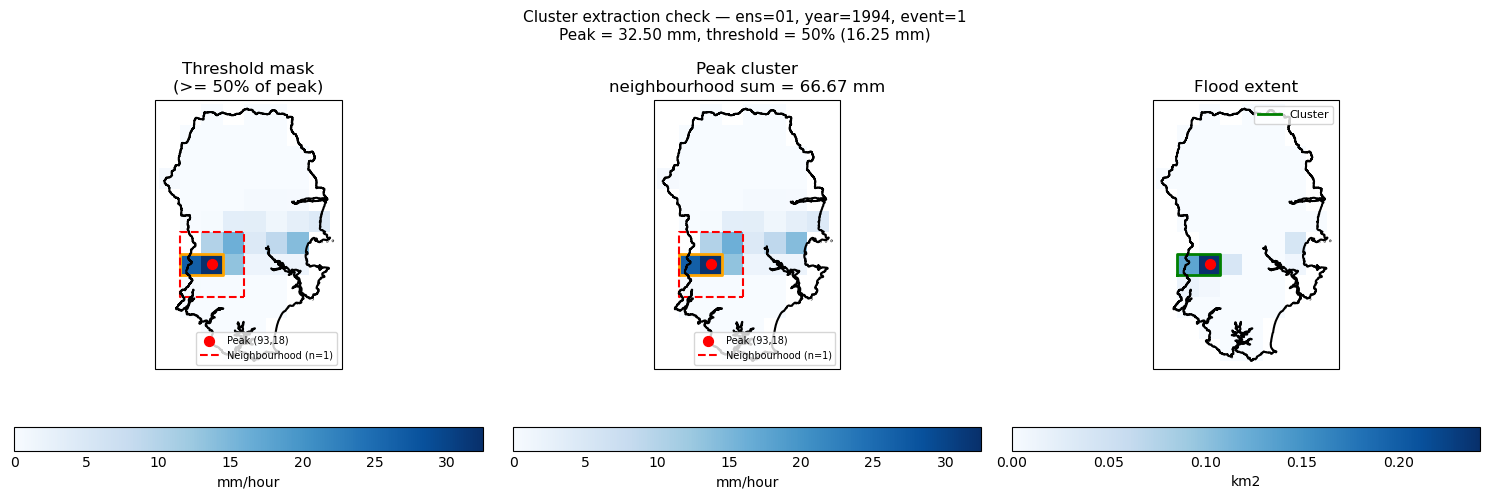

EM01 | year 1994: 1 events in 8.7s
Running for 1995 for 01 for 46
Pipeline 2 peak coord: 257500.0 77500.0


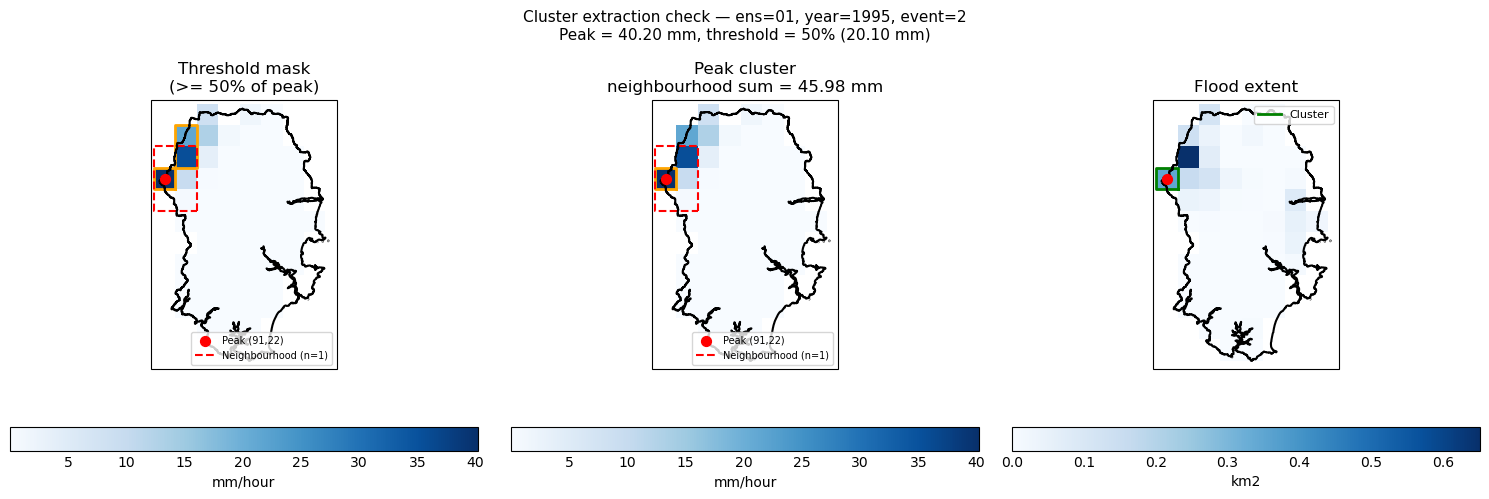

EM01 | year 1995: 1 events in 7.1s
Running for 1998 for 01 for 46
Pipeline 2 peak coord: 267500.0 72500.0


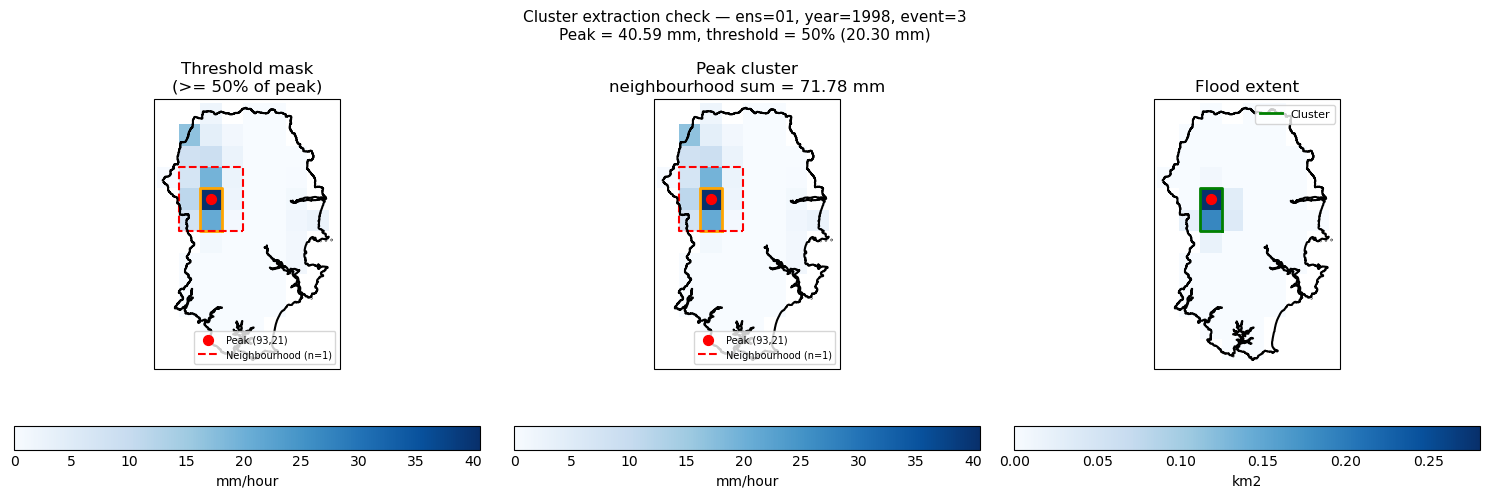

EM01 | year 1998: 1 events in 9.3s
Running for 1999 for 01 for 46
Pipeline 2 peak coord: 262500.0 67500.0


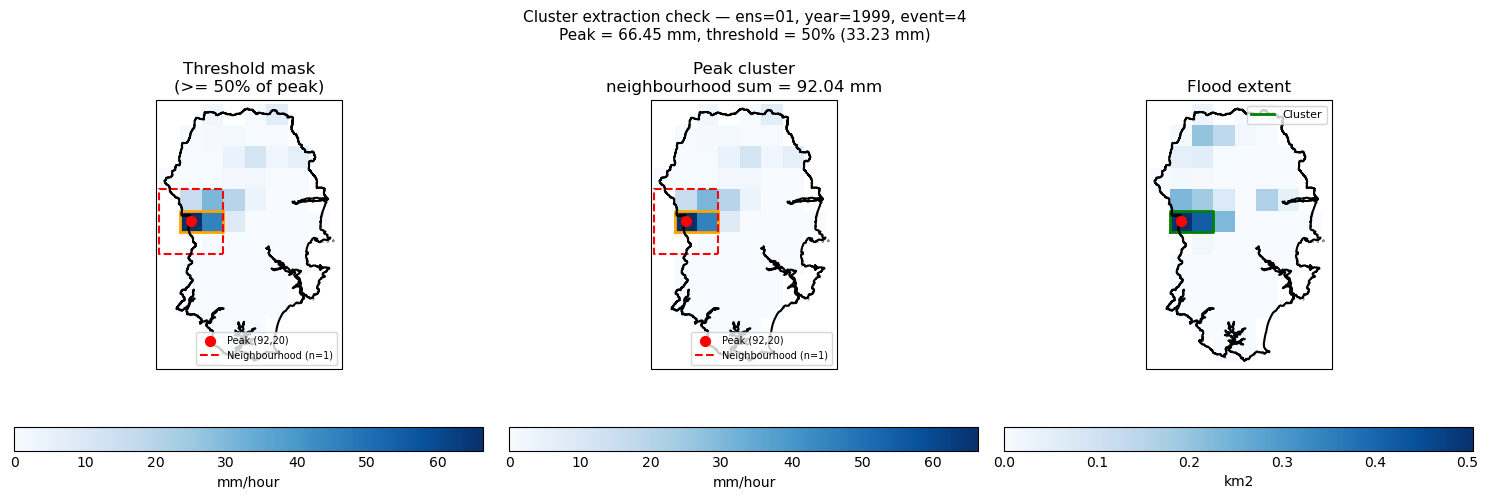

Pipeline 2 peak coord: 262500.0 82500.0


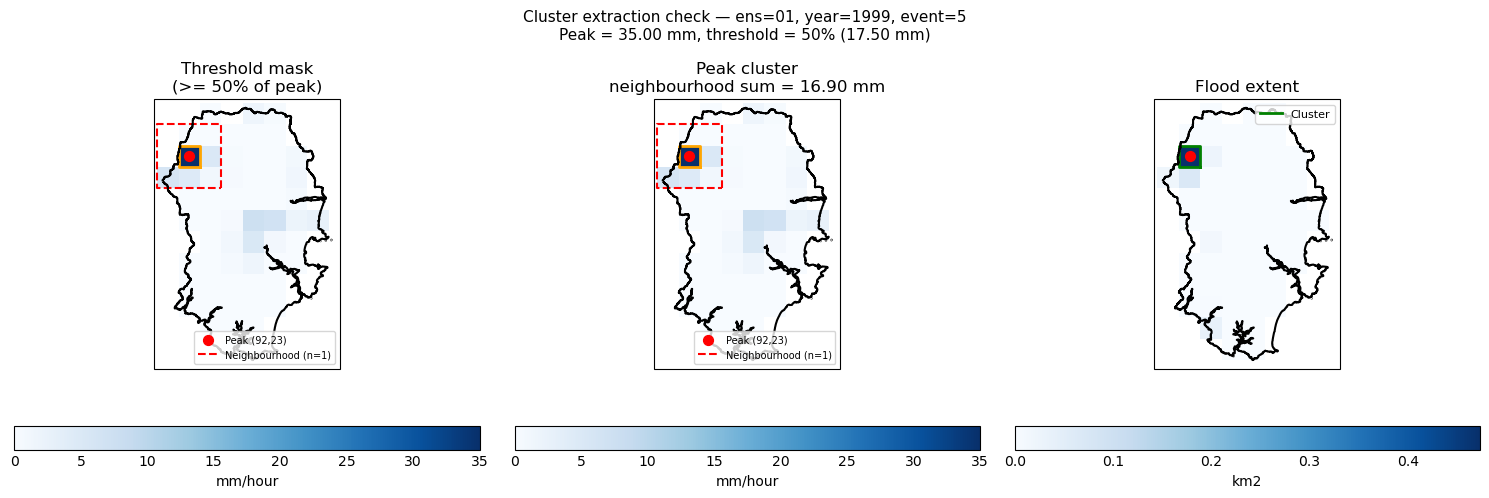

EM01 | year 1999: 2 events in 11.7s
Running for 2000 for 01 for 46
Pipeline 2 peak coord: 262500.0 82500.0


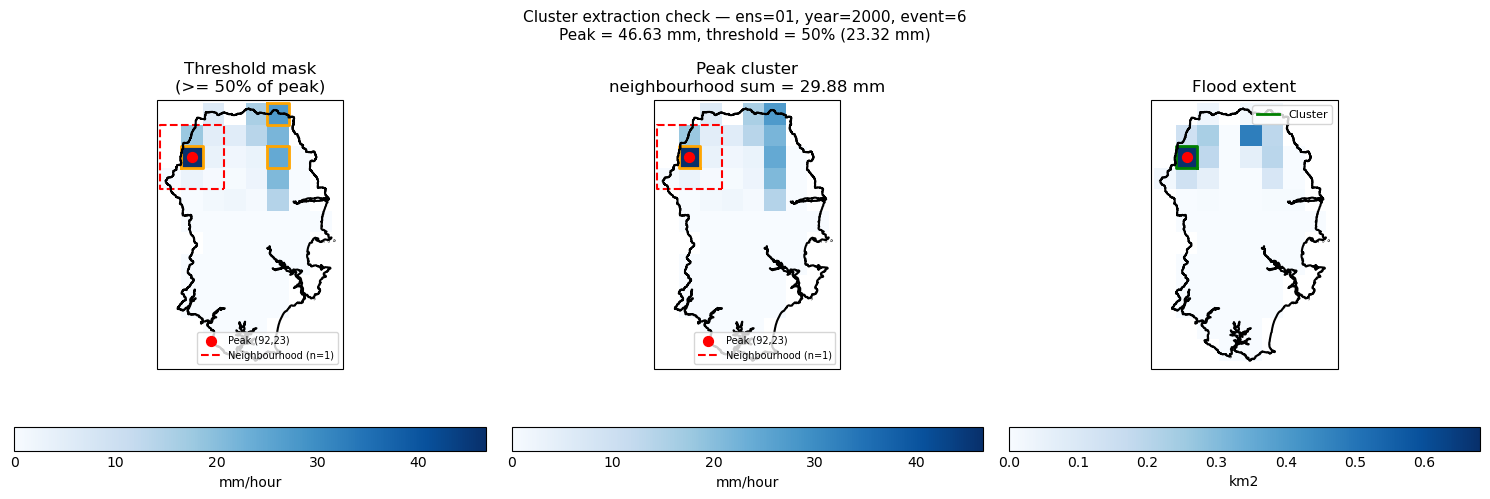

EM01 | year 2000: 1 events in 6.9s
Running for 2002 for 01 for 46
Pipeline 2 peak coord: 277500.0 47500.0


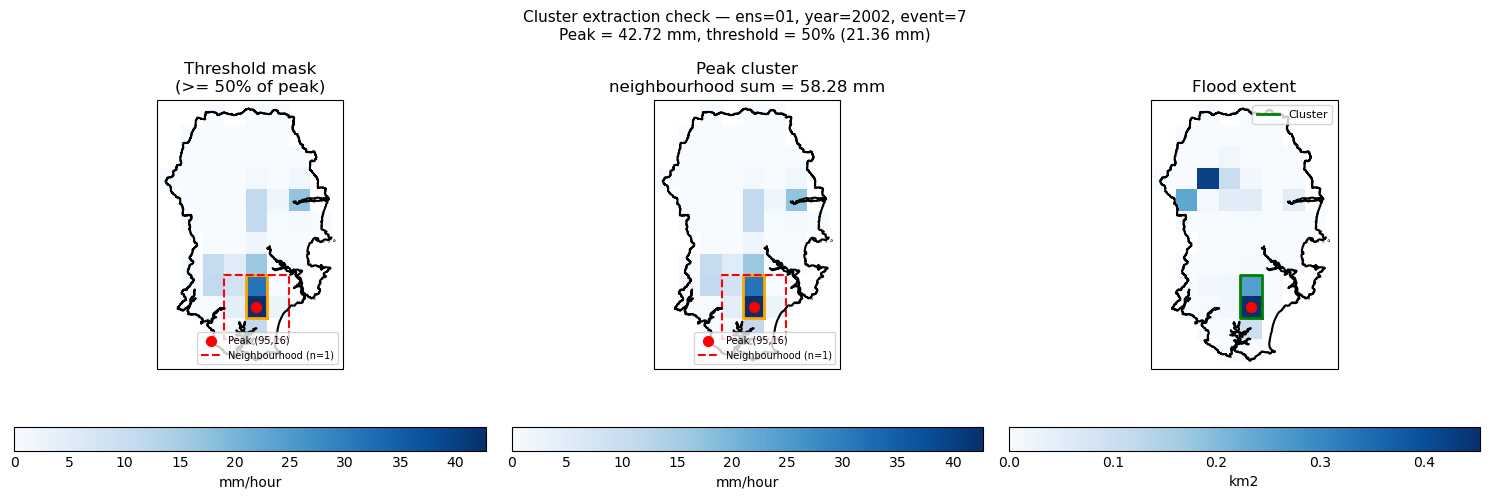

EM01 | year 2002: 1 events in 8.8s
Running for 2003 for 01 for 46


KeyboardInterrupt: 

In [8]:
import numpy as np
import pandas as pd
import cftime
import re
import time
import gc
import os
import sys
import math
import glob
import datetime
from scipy.ndimage import label, generate_binary_structure

from functions import *
from functions_stage2 import (get_rainfall_cube_subsection, setup_worker_logger, find_max_precip_location_new, 
                        find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check)
verbose=True

def emit(msg):
    """Single call routes to print or log depending on verbose flag."""
    if verbose:
        print(msg)
    else:
        log.info(msg)

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 


## ------------------------------------------------------------ ###
# Define which catchments to run
## ------------------------------------------------------------ ###
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())
files = os.listdir(OUT_DIR)
completed_catchments = {re.search(r'Catchment_(.+)', f).group(1) for f in files if re.search(r'Catchment_(.+)', f)}
catchments_to_run = (all_catchments - completed_catchments) - {105} - {14}

catchments_with_flood_output = []

## Loop through all catchments
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp):
        catchments_with_flood_output.append(catchment_num)

# ── Check which (catchment, ens) combinations still need processing ───────────
# Assumes outputs are saved as: OUT_DIR/Catchment_{num}/Ens_{ens}.pkl
# If your output structure is different, adjust the path accordingly.

missing = {}  # {catchment_num: [list of missing ens]}
to_prioritise ={}

DATASET_MIN_YEAR = 1990

HOURS_PER_MONTH = 30 * 24  # 720, matches get_rainfall_cube_subsection

def get_rainfall_lookback_cube(year, ens_num, rainfall_cube_dir, event_start_idx, lookback_hours):
    """
    Fetch a rainfall cube covering [event_start_idx - lookback_hours, event_start_idx)
    in the same global-index convention as get_rainfall_cube_subsection(year, ...).

    Handles the case where the lookback window crosses back before the start
    of `year`'s cube (i.e. before 1 Dec of year-1) by pulling the tail of
    year-1's own cube. Assumes lookback_hours < HOURS_PER_MONTH (true for
    windows up to ~29 days), so at most one boundary crossing is needed.
    """
    if lookback_hours >= HOURS_PER_MONTH:
        raise ValueError(
            f"lookback_hours={lookback_hours} >= {HOURS_PER_MONTH}; this helper "
            f"only handles a single hydro-year boundary crossing."
        )

    lookback_start_idx = event_start_idx - lookback_hours

    if lookback_start_idx >= 0:
        # Entirely within this year's cube — no boundary crossing needed
        return get_rainfall_cube_subsection(
            year, ens_num, rainfall_cube_dir,
            start_idx=lookback_start_idx, stop_idx=event_start_idx)

    # Need to reach back into year-1's own cube
    if year - 1 <= DATASET_MIN_YEAR:
        raise ValueError(
            f"Lookback window for year={year} needs data before "
            f"{DATASET_MIN_YEAR}1201, which is before the dataset start."
        )

    deficit = -lookback_start_idx  # hours needed from before this year's cube starts

    # Work out year-1's own cube length so we know where its Dec(year-1)
    # block (the tail) sits in its own index space
    prev_has_prev_december = not (year - 1 == DATASET_MIN_YEAR)
    prev_total_len = (13 if prev_has_prev_december else 12) * HOURS_PER_MONTH

    prev_cube = get_rainfall_cube_subsection(
        year - 1, ens_num, rainfall_cube_dir,
        start_idx=prev_total_len - deficit, stop_idx=prev_total_len)

    this_cube = get_rainfall_cube_subsection(
        year, ens_num, rainfall_cube_dir,
        start_idx=0, stop_idx=event_start_idx)

    for c in (prev_cube, this_cube):
        c.attributes = {}
        c.coord('time').bounds = None

    return iris.cube.CubeList([prev_cube, this_cube]).concatenate_cube()

def analyse_peak_event(
    this_event_results,
    year_cube,
    flood_numpy,
    flood_cubes,
    CATCHMENT_POLY,
    boundary_gdf,
    neighbourhood_size,
    threshold_levels,
    antecedent_arrays=None,   # dict: {'ante_rain_1d': 2D array, 'ante_rain_5d': 2D array, 'ante_sm': 2D array, ...}
    plot=False
):
    peak_value = this_event_results['max_precip']
    t_local    = int(this_event_results['t_local'])
    yi         = int(this_event_results['y_idx'])
    xi         = int(this_event_results['x_idx'])
    
    p2_x = year_cube.coord('projection_x_coordinate').points[xi]
    p2_y = year_cube.coord('projection_y_coordinate').points[yi]
    print("Pipeline 2 peak coord:", p2_x, p2_y)    

    peak_slice = year_cube[t_local, :, :]
    rain = peak_slice.data.astype(float)
    rain = np.where((rain == -99999) | (rain > 1e19), np.nan, rain)

    flood_arrays = {
        (depth, var): flood_numpy[depth][var][this_event_results['event_num'] - 1, :, :]
        for depth in [10, 30]
        for var in ['area', 'vol']
    }

    n  = neighbourhood_size
    y0 = max(0, yi - n);  y1 = min(rain.shape[0], yi + n + 1)
    x0 = max(0, xi - n);  x1 = min(rain.shape[1], xi + n + 1)
    neighbourhood = rain[y0:y1, x0:x1]

    results = {
        'neighbourhood_rain_total': float(np.nansum(neighbourhood)),
        'neighbourhood_rain_sum_excl_peak': float(np.nansum(neighbourhood) - peak_value),
        'neighbourhood_n_cells': int(np.sum(~np.isnan(neighbourhood))),
    }

    for depth in [10, 30]:
        for var in ['area', 'vol']:
            results[f'neighbourhood_flood_{depth}_{var}'] = float(
                np.nansum(flood_arrays[(depth, var)][y0:y1, x0:x1]))

    # ── Antecedent stats at neighbourhood scale ─────────────────────────────
    if antecedent_arrays:
        for ante_name, ante_grid in antecedent_arrays.items():
            ante_nbhd = ante_grid[y0:y1, x0:x1]
            results[f'neighbourhood_{ante_name}_mean'] = float(np.nanmean(ante_nbhd))
            results[f'neighbourhood_{ante_name}_point'] = float(ante_grid[yi, xi])  # single-cell case

    for threshold_level in threshold_levels:
        t_suffix = f"_t{int(threshold_level * 100)}"
        threshold_value = peak_value * threshold_level
        threshold_mask = (rain >= threshold_value) & (~np.isnan(rain))

        labeled, _ = label(threshold_mask)
        peak_label = labeled[yi, xi]
        cluster_mask = (labeled == peak_label)

        results[f'threshold_rain_total{t_suffix}'] = float(np.nansum(rain[threshold_mask]))
        results[f'threshold_n_cells{t_suffix}']    = int(np.sum(threshold_mask))
        results[f'cluster_rain_total{t_suffix}']   = float(np.nansum(rain[cluster_mask]))
        results[f'cluster_n_cells{t_suffix}']      = int(np.sum(cluster_mask))

        for depth in [10, 30]:
            for var in ['area', 'vol']:
                fa = flood_arrays[(depth, var)]
                results[f'threshold_flood_{depth}_{var}{t_suffix}'] = float(np.nansum(fa[threshold_mask]))
                results[f'cluster_flood_{depth}_{var}{t_suffix}']   = float(np.nansum(fa[cluster_mask]))

        # ── Antecedent stats at threshold/cluster scale ─────────────────────
        if antecedent_arrays:
            for ante_name, ante_grid in antecedent_arrays.items():
                results[f'threshold_{ante_name}_mean{t_suffix}'] = float(np.nanmean(ante_grid[threshold_mask]))
                results[f'cluster_{ante_name}_mean{t_suffix}']   = float(np.nanmean(ante_grid[cluster_mask]))

        if plot and threshold_level == 0.5:
            plot_cluster_check(
                rain=rain, peak_slice=peak_slice,
                threshold_mask=threshold_mask, cluster_mask=cluster_mask,
                row=this_event_results, y0=y0, y1=y1, x0=x0, x1=x1,
                threshold_level=threshold_level,
                neighbourhood_sum=results['neighbourhood_rain_sum_excl_peak'],
                neighbourhood_size=neighbourhood_size,
                flood=flood_cubes[10]['area'][this_event_results['event_num'] - 1],
                catchment_poly=CATCHMENT_POLY, boundary_gdf=boundary_gdf)

    assert cluster_mask[yi, xi] == True
    assert results['neighbourhood_n_cells'] > 0
    assert results['neighbourhood_n_cells'] <= (2*n+1)**2
    assert results['cluster_rain_total_t50'] <= results['threshold_rain_total_t50']

    return results

for catchment_num in ['46']:

    print(f"Running for {catchment_num}")

    start_catchment_time = time.time()

    log = setup_worker_logger(catchment_num)

    catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    emit(f"Starting: {catchment_name}")
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    results = []

    begin_time = time.time()
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2)
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)#
    
    ny_sub = year_cube.shape[1]
    nx_sub = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, 
                                mask_x_offset:mask_x_offset + nx_sub]
    emit(f"Mask created in {time.time()-begin_time:.1f}s")
    del full_rain_cube, year_cube

    flood_dir    = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/"

    flood_numpy = {}
    flood_cubes = {}
    current_ens = None
    DIAGNOSE_EVENT = [0]
    n_days_ls      = [2, 3, 4, 5]       # antecedent SM windows
    rain_n_days_ls = [1, 2, 5, 10]      # NEW — antecedent rainfall windows
    all_results    = []

    for ens_num in ['01']:

        fp = os.path.join(OUT_DIR,f"Catchment_{catchment_num}",f"{catchment_name}_EM{ens_num}_new.pkl")

        if os.path.exists(fp):
            print(f"Loading {catchment_name}, EM{ens_num}")
            df = pd.read_pickle(fp)
            results.append(df)                

        else:
            catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]

            start_time_ens = time.time()
            results_this_ens = []

            rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
            rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
            rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
                    rainfall_events['start_year'] + 1)
            print(f"rainfall events is length: {len(rainfall_events)}")

            rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
            emit(f"EM{ens_num}: {len(rainfall_events)} events to process")

            event_details_cache = {
                ev: get_rainfall_event_details(rainfall_events, ev)
                for ev in rainfall_events['event_num']}

            for year, events_in_year in rainfall_events.groupby('hydro_year'):
                begin_time = time.time()

                sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens_num}/'
                sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
                sm      = iris.load(sm_file)[0]

                needs_extra_sm = ((events_in_year['start_month'] == 12) & (events_in_year['start_day'] == 1)).any()

                if needs_extra_sm:
                    prev_sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-2}1201-{year-1}1130_mrso.nc")
                    if prev_sm_file:
                        prev_sm = iris.load(prev_sm_file[0])[0]
                        prev_sm.attributes = {}
                        sm.attributes = {}
                        sm = iris.cube.CubeList([prev_sm, sm]).concatenate_cube()
                        print(f"  Loaded extra SM file for year {year-2}-{year-1} (early-December event)")
                    else:
                        print(f"  WARNING: needed prior SM file for {year-2}-{year-1} but not found")

                sm.data      = np.where(FULL_MASK_2D, sm.data, np.nan)
                sm           = filter_closer_to_catchment(sm, CATCHMENT_POLY, plot=False)
                sm_data      = sm.data
                sm_time_arr  = np.array([cell.point for cell in sm.coord('time').cells()])

                print(f"Running for {year} for {ens_num} for {catchment_num}")
                for row in events_in_year.itertuples():
                    event_num     = int(row.event_num)
                    event_details = event_details_cache[event_num]

                    year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, 
                                                         event_details['start_idx']-1, event_details['stop_idx'])
                    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
                    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
                    time_coord  = year_cube.coord('time')

                    t0 = time_coord.units.num2date(np.floor(time_coord.points[0]))
                    t_end = time_coord.units.num2date(time_coord.points[-1])
                    event_start = cftime.Datetime360Day(event_details['start_year'], 
                                                 event_details['start_month'], 
                                                 event_details['start_day'], 
                                                 event_details['start_hour'])
                    event_start_within_cube = t0 <= event_start <= t_end

                    this_event_results = find_max_precip_location_new(
                        year_cube, event_details['start_idx'], event_details['stop_idx'],
                        x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)

                    this_event_results['ens']       = ens_num
                    this_event_results['start_idx'] = event_details['start_idx']
                    this_event_results['stop_idx']  = event_details['stop_idx']
                    this_event_results['max_precip_from_csv']  = event_details['max_precip_from_csv']
                    this_event_results['start_year']  = event_details['start_year']
                    this_event_results['start_month']  = event_details['start_month']
                    this_event_results['start_day']  = event_details['start_day']
                    this_event_results['start_hour']  = event_details['start_hour']
                    this_event_results['event_num']  = event_details['event_num']
                    if not event_start_within_cube:
                        this_event_results['time_mismatch'] = True
                        print("TIME MISMACH")
                    else:
                        this_event_results['time_mismatch'] = False

                    t = time_coord.units.num2date(time_coord.points[this_event_results['t_local']])
                    this_event_results['rainfall_peak_day'] = cftime.Datetime360Day(t.year, t.month, t.day)
                    this_event_results['hydro_day_360'] = (
                        (this_event_results['rainfall_peak_day'].month % 12) * 30
                        + this_event_results['rainfall_peak_day'].day)
                    this_event_results['day_360'] = (
                        (this_event_results['rainfall_peak_day'].month - 1) * 30
                        + this_event_results['rainfall_peak_day'].day)
                    this_event_results['t_local_rebased']    = this_event_results['t_global'] - this_event_results['start_idx']

                    rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
                    if this_event_results['event_num'] in DIAGNOSE_EVENT:
                        temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)
                    else:
                        temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=False)

                    this_event_results.update(temp_profile_dict)    

                    if not math.isclose(float(np.float32(this_event_results['max_precip'])), 
                                         float(np.float32(this_event_results['max_precip_from_csv'])),
                                         abs_tol=0.001):
                        print(f"MISMATCH — ens={ens_num}, year={year}, event={event_num}")
                        print(f"  cube: {this_event_results['max_precip']:.8f}")
                        print(f"  csv:  {this_event_results['max_precip_from_csv']:.8f}")
                        this_event_results['mismatch'] = True
                    else:
                        this_event_results['mismatch'] = False

                    if ens_num != current_ens:
                        if flood_cubes:
                            del flood_cubes, flood_numpy
                            gc.collect()
                        ens_flood_dir = f"{flood_dir}/Ens{ens_num}_{catchment_num}/"
                        flood_cubes = {}
                        flood_numpy = {}
                        for depth in [10, 30]:
                            area_cube = prepare_flood_cube(load_3d_cube(
                                f"{ens_flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
                            area_cube.data = np.where(FULL_MASK_2D, area_cube.data, np.nan)
                            area_cube = filter_closer_to_catchment(area_cube, CATCHMENT_POLY, plot=False)
                            print(f"Area cube shape: {area_cube.shape}")
                            vol_cube  = prepare_flood_cube(load_3d_cube(
                                f"{ens_flood_dir}/{depth}cm/flooded_volume_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
                            vol_cube.data = np.where(FULL_MASK_2D, vol_cube.data, np.nan)
                            vol_cube = filter_closer_to_catchment(vol_cube, CATCHMENT_POLY, plot=False)
                            flood_cubes[depth] = {'area': area_cube, 'vol': vol_cube}
                            flood_numpy[depth] = {'area': area_cube.data, 'vol': vol_cube.data}
                        current_ens = ens_num     

                    maybe_diagnose(
                        this_event_results,
                        event_num=this_event_results['event_num'],
                        condition=(this_event_results['event_num'] in DIAGNOSE_EVENT),
                        sm=sm,
                        flood_cubes=flood_cubes,
                        catchment_poly=CATCHMENT_POLY,
                        ens_num=ens_num,
                        rainfall_cube_dir=rainfall_cube_dir, 
                        FULL_MASK_2D= FULL_MASK_2D)

                    xi = int(this_event_results['x_idx'])
                    yi = int(this_event_results['y_idx'])

                    sm_at_peak_data   = sm_data[:, yi, xi]
                    rainfall_peak_360 = this_event_results['rainfall_peak_day']

                    mean_sm_stats = {}
                    for n_days in n_days_ls:
                        delta       = datetime.timedelta(days=n_days)
                        mask        = (sm_time_arr >= (rainfall_peak_360 - delta)) & (sm_time_arr < rainfall_peak_360)
                        subset_data = sm_at_peak_data[mask]

                        if subset_data.size == 0:
                            print(f"  Warning: empty SM window for event={row.event_num}, "
                                  f"n_days={n_days}, peak={rainfall_peak_360}")
                            mean_sm_stats[f'mean_sm_{n_days}_before_event'] = float('nan')
                            continue

                        mean_sm_stats[f'mean_sm_{n_days}_before_event'] = float(subset_data.mean())

                    flood_stats = {}
                    for depth in [10, 30]:
                        flood_stats[f"{depth}cm_area"]   = flood_numpy[depth]['area'][this_event_results['event_num'] - 1, yi, xi]
                        flood_stats[f"{depth}cm_volume"] = flood_numpy[depth]['vol'][this_event_results['event_num'] - 1, yi, xi]

                    this_event_results.update(flood_stats)
                    this_event_results.update(mean_sm_stats)

                    if this_event_results['event_num'] in DIAGNOSE_EVENT:
                        plot=True
                    else:
                        plot = False

                    # ── NEW: antecedent rainfall — fetch lookback cube for this event ──────
                    max_lookback_hours = max(rain_n_days_ls) * 24
                    ante_cube = get_rainfall_lookback_cube(
                        year, ens_num, rainfall_cube_dir,
                        event_start_idx=event_details['start_idx'], lookback_hours=max_lookback_hours)
                    ante_cube.data = np.where(FULL_MASK_2D, ante_cube.data, np.nan)
                    ante_cube, ax_off, ay_off = subset_cube_to_bbox(ante_cube, CATCHMENT_POLY, buffer=0)
                    ante_data = ante_cube.data  # (max_lookback_hours, y, x), oldest → newest

                    # Alignment check — event-window cube and lookback cube should share
                    # the same bbox subset since both use the same CATCHMENT_POLY/buffer=0
                    assert ante_data.shape[1:] == (rain if False else year_cube.shape[1:]), \
                        f"Lookback cube shape {ante_data.shape[1:]} != event cube shape {year_cube.shape[1:]}"

                    antecedent_arrays = {}
                    for n_days in rain_n_days_ls:
                        hrs = n_days * 24
                        antecedent_arrays[f'ante_rain_{n_days}d'] = np.nansum(ante_data[-hrs:, :, :], axis=0)

                    sm_idx_before_event = np.searchsorted(sm_time_arr, rainfall_peak_360) - 1
                    antecedent_arrays['ante_sm'] = sm_data[sm_idx_before_event, :, :]

                    peak_results = analyse_peak_event(
                        this_event_results, year_cube, flood_numpy, flood_cubes,
                        CATCHMENT_POLY, boundary_gdf, neighbourhood_size=1,
                        threshold_levels=[0.5, 0.6, 0.8],
                        antecedent_arrays=antecedent_arrays,
                        plot=True)

                    this_event_results.update(peak_results)    
                    results_this_ens.append(this_event_results)

                    del ante_cube, ante_data  # keep memory flat across the event loop

                emit(f"EM{ens_num} | year {year}: {len(events_in_year)} events in {time.time()-begin_time:.1f}s")
                del year_cube



In [2]:
import numpy as np
import pandas as pd
import cftime
import re
import time
import gc
import os
import sys
import math
import glob
import datetime
import pickle

from functions import *
from functions_stage2 import (get_rainfall_cube_subsection, setup_worker_logger, find_max_precip_location_new, 
                        find_temporal_profile_new, maybe_diagnose, analyse_peak_event,
                             plot_cluster_check)
verbose=True

def emit(msg):
    """Single call routes to print or log depending on verbose flag."""
    if verbose:
        print(msg)
    else:
        log.info(msg)

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 


## ------------------------------------------------------------ ###
# Define which catchments to run
## ------------------------------------------------------------ ###
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())
files = os.listdir(OUT_DIR)
completed_catchments = {re.search(r'Catchment_(.+)', f).group(1) for f in files if re.search(r'Catchment_(.+)', f)}
catchments_to_run = (all_catchments - completed_catchments) # - {105} - {14}

catchments_with_flood_output = []

## Loop through all catchments
for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
    fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails/Catchment_{catchment_num}/{catchment_name}.pkl"
    flood_fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/Ens01_{catchment_num}/10cm/flooded_area_5km_total_Ens01_{catchment_num}_10cm.nc"
        
    if os.path.isfile(flood_fp):
        catchments_with_flood_output.append(catchment_num)

# ── Check which (catchment, ens) combinations still need processing ───────────
# Assumes outputs are saved as: OUT_DIR/Catchment_{num}/Ens_{ens}.pkl
# If your output structure is different, adjust the path accordingly.

missing = {}  # {catchment_num: [list of missing ens]}
to_prioritise ={}

for catchment_num in catchments_with_flood_output:

    catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]

    # Load just enough to know which ens members exist for this catchment
    all_ens = ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '15']
    overall_fp =  f"{OUT_DIR}/Catchment_{catchment_num}/{catchment_name}.pkl"
    if os.path.isfile(overall_fp):
        # print(f"Catchment {catchment_num} ({catchment_name}) is complete")
        pass
    else:

        missing_ens = []
        for ens in sorted(all_ens):
            out_fp = f"{OUT_DIR}/Catchment_{catchment_num}/{catchment_name}_EM{ens}.pkl"
            if not os.path.isfile(out_fp):
                missing_ens.append(ens)

        if missing_ens:
            missing[catchment_num] = missing_ens
            #print(f"Catchment {catchment_num} ({catchment_name}): missing ens {missing_ens}")
        else:
            pass
            #print(f"Catchment {catchment_num} ({catchment_name}): complete")

    # Summary
    total_missing = sum(len(v) for v in missing.values())
    # print(f"\n{len(missing)} catchments incomplete, {total_missing} (catchment, ens) jobs remaining")        

    # Sort catchments by number of missing ens (ascending) so we tackle the
    # nearly-complete ones first — minimises total remaining work to get results.
    sorted_missing = sorted(missing.items(), key=lambda x: len(x[1]))

    # print("\nCatchments sorted by missing ens (least first):")
    # print(f"{'Catchment':<15} {'Name':<30} {'Missing ens':<15} {'Ens list'}")
    # print("-" * 80)
    for catchment_num, missing_ens in sorted_missing:
        catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
        #print(f"{catchment_num:<15} {catchment_name:<30} {len(missing_ens):<15} {missing_ens}")

    # Also gives you a clean list to feed directly into your processing loop
    catchments_to_run_sorted = [catchment_num for catchment_num, _ in sorted_missing]
print(catchments_to_run_sorted)


[]


In [2]:
for catchment_num in ['89']: # catchments_to_run_sorted:# catchments_to_run_sorted[4:]:
    
    print(f"Running for {catchment_num}")
    if not os.path.exists(os.path.join(OUT_DIR, f"Catchment_{catchment_num}")):
        os.mkdir(os.path.join(OUT_DIR, f"Catchment_{catchment_num}"))
    start_catchment_time = time.time()

    # ── Set up output routing ─────────────────────────────────────────────────
    # When running in parallel, verbose=False routes all output to a per-catchment
    # log file so workers don't interleave. When debugging in a notebook,
    # verbose=True prints directly so you see output immediately.
    log = setup_worker_logger(catchment_num)

    # Get data for the catchment
    catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
    emit(f"Starting: {catchment_name}")
    boundary_gdf    = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]

    # Create a list which will store all results (across ensemble members)
    results = []

    # ───────────────────────────────────────────────── 
    # Create a mask for this catchment (over whole UK)
    # Create a version of it over the area filtered to the catchment
    # These are used later
    # ───────────────────────────────────────────────── 
    begin_time = time.time()
    full_rain_cube = get_rainfall_cube_subsection(2015, '01', f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/", 1, 2) #any year, any ensemble member
    FULL_MASK_2D   = mask_cube_with_catchment_full_grid(full_rain_cube[0], CATCHMENT_POLY, method='center_point')
    year_cube, mask_x_offset, mask_y_offset = subset_cube_to_bbox(full_rain_cube, CATCHMENT_POLY, buffer=0)
    ny_sub = year_cube.shape[1]
    nx_sub = year_cube.shape[2]
    mask_2d_sub = FULL_MASK_2D[mask_y_offset:mask_y_offset + ny_sub, 
                                mask_x_offset:mask_x_offset + nx_sub]
    emit(f"Mask created in {time.time()-begin_time:.1f}s")
    del full_rain_cube, year_cube

    # ─────────────────────────────────────────────────
    # Get hydraulic conductivity data
    # ─────────────────────────────────────────────────
    HC_CUBE      = iris.load(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/HydraulicConductivity/5km_{catchment_num}.nc")[0]
    HC_CUBE.data = np.where(FULL_MASK_2D, HC_CUBE.data, np.nan)
    HC_CUBE = filter_closer_to_catchment(HC_CUBE, CATCHMENT_POLY, plot=False)
    HC_DATA      = HC_CUBE.data  # realise once — shape (y, x)
    flood_dir    = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/PluvialResults/5km_total/Catchment_{catchment_num}/"

    # ─────────────────────────────────────────────────
    # HMM?
    # ─────────────────────────────────────────────────
    flood_numpy = {}  # will hold realised numpy arrays, keyed [depth]['area'/'vol']
    flood_cubes = {}  # still needed for maybe_diagnose (expects iris cubes)
    current_ens = None
    DIAGNOSE_EVENT = [0]
    n_days_ls      = [2, 3, 4, 5]
    all_results    = []

    # ───────────────────────────────────────────────── 
    # Loop over EMs (wrap in try/pass to deal with errors from mismatch of max precip)
    # ───────────────────────────────────────────────── 

    for ens_num in ENSEMBLE_MEMBERS:

        fp = os.path.join(OUT_DIR,f"Catchment_{catchment_num}",f"{catchment_name}_EM{ens_num}.pkl")

        if os.path.exists(fp):
            print(f"Loading {catchment_name}, EM{ens_num}")

            df = pd.read_pickle(fp)
            results.append(df)                
                
        else:
            catchment_name = CATCHMENT_LOOKUP_DICT[catchment_num]
        
            start_time_ens = time.time()
            # Create a list which will store all results from this ensemble member
            results_this_ens = []

            # Read in the csv with event details for this catchment/ensemble member
            rainfall_events  = pd.read_csv(RAINFALL_CSV_DIR + f"{catchment_name}_{ens_num}_full_events_with_event_nums.csv")
            rainfall_events['event_num']  = range(1, len(rainfall_events) + 1)
            rainfall_events['hydro_year'] = rainfall_events['start_year'].where(rainfall_events['start_month'] != 12,
                    rainfall_events['start_year'] + 1)
            print(f"rainfall events is length: {len(rainfall_events)}")
            
            # Specify filepath to the directory with netCDF for this ensemble member
            rainfall_cube_dir = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
            emit(f"EM{ens_num}: {len(rainfall_events)} events to process")

            # Create cached version of event details, for all events
            event_details_cache = {
                ev: get_rainfall_event_details(rainfall_events, ev)
                for ev in rainfall_events['event_num']}

            # ───────────────────────────────────────────────── 
            # Loop through each event
            # ───────────────────────────────────────────────── 
            for year, events_in_year in rainfall_events.groupby('hydro_year'):
                begin_time = time.time()
                # ─────────────────────────────────────────────────
                # ── Load SM cube and realise to numpy once per (ens, year) 
                # ─────────────────────────────────────────────────
                sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens_num}/'
                sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
                sm      = iris.load(sm_file)[0]

                # Check if we also need the previous hydro year's SM
                # (i.e. event peak is early December, so lookback window bleeds into Nov or earlier)
                needs_extra_sm = ((events_in_year['start_month'] == 12) & (events_in_year['start_day'] == 1)).any()

                if needs_extra_sm:
                    # Load the prior hydro year file: Dec(yr-2) to Nov(yr-1)
                    prev_sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-2}1201-{year-1}1130_mrso.nc")
                    if prev_sm_file:
                        prev_sm = iris.load(prev_sm_file[0])[0]
                        prev_sm.attributes = {}
                        sm.attributes = {}
                        sm = iris.cube.CubeList([prev_sm, sm]).concatenate_cube()
                        print(f"  Loaded extra SM file for year {year-2}-{year-1} (early-December event)")
                    else:
                        print(f"  WARNING: needed prior SM file for {year-2}-{year-1} but not found")

                sm.data      = np.where(FULL_MASK_2D, sm.data, np.nan)
                sm           = filter_closer_to_catchment(sm, CATCHMENT_POLY, plot=False)
                sm_data      = sm.data
                sm_time_arr  = np.array([cell.point for cell in sm.coord('time').cells()])

                print(f"Running for {year} for {ens_num} for {catchment_num}")
                for row in events_in_year.itertuples():
                    # Get the event details from the cache
                    event_num     = int(row.event_num)
                    event_details = event_details_cache[event_num]

                    # Get a portion of the cube, over the catchment, between the times when the maximum happened
                    year_cube = get_rainfall_cube_subsection(year, ens_num, rainfall_cube_dir, 
                                                         event_details['start_idx']-1, event_details['stop_idx'])
                    year_cube.data = np.where(FULL_MASK_2D, year_cube.data, np.nan)
                    year_cube, x_offset, y_offset = subset_cube_to_bbox(year_cube, CATCHMENT_POLY, buffer=0)
                    # Extract the times for this subset
                    time_coord  = year_cube.coord('time')

                    # t0 = time_coord.units.num2date(time_coord.bounds[0, 0]) 
                    t0 = time_coord.units.num2date(np.floor(time_coord.points[0]))
                    t_end = time_coord.units.num2date(time_coord.points[-1])
                    peak = cftime.Datetime360Day(event_details['yr'], event_details['month'], event_details['day'], event_details['hour'])
                    peak_within_cube = t0 <= peak <= t_end

                    # Find the location of the max precipitation value
                    # This masks out all cells not inside the catchment
                    this_event_results = find_max_precip_location_new(
                        year_cube, event_details['start_idx'], event_details['stop_idx'],
                        x_offset=x_offset, y_offset=y_offset, mask_2d=mask_2d_sub)

                    # Add key details to the results dictionary
                    this_event_results['ens']       = ens_num
                    this_event_results['start_idx'] = event_details['start_idx']
                    this_event_results['stop_idx']  = event_details['stop_idx']
                    this_event_results['max_precip_from_csv']  = event_details['max_precip_from_csv']
                    this_event_results['start_year']  = event_details['yr']
                    this_event_results['month']  = event_details['month']
                    this_event_results['event_num']  = event_details['event_num']
                    if not peak_within_cube:
                        this_event_results['time_mismatch'] = True
                        print("TIME MISMACH")
                    else:
                        this_event_results['time_mismatch'] = False


                    # Get the day on which the peak occurred
                    # This uses t_local to reference the times from the subset
                    t = time_coord.units.num2date(time_coord.points[this_event_results['t_local']])
                    this_event_results['rainfall_peak_day'] = cftime.Datetime360Day(t.year, t.month, t.day)
                    this_event_results['hydro_day_360'] = (
                        (this_event_results['rainfall_peak_day'].month % 12) * 30
                        + this_event_results['rainfall_peak_day'].day)
                    this_event_results['day_360'] = (
                        (this_event_results['rainfall_peak_day'].month - 1) * 30
                        + this_event_results['rainfall_peak_day'].day)
                    this_event_results['t_local_rebased']    = this_event_results['t_global'] - this_event_results['start_idx']

                    # Get 1D cube, just at the location of the peak
                    rainfall_at_peak  = get_data_at_peak_cell(year_cube, this_event_results, 'x_idx', 'y_idx')
                    # Extract various temporal profile results
                    if this_event_results['event_num'] in DIAGNOSE_EVENT:
                        temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=True)
                    else:
                        temp_profile_dict = find_temporal_profile_new(rainfall_at_peak, this_event_results, plot=False)

                    # Add these to dictionary of results 
                    this_event_results.update(temp_profile_dict)    

                    # Check whether the maximum precipitation matches the values in the input csv
                    if not math.isclose(float(np.float32(this_event_results['max_precip'])), 
                                         float(np.float32(this_event_results['max_precip_from_csv'])),
                                         abs_tol=0.001):
                        print(f"MISMATCH — ens={ens_num}, year={year}, event={event_num}")
                        print(f"  cube: {this_event_results['max_precip']:.8f}")
                        print(f"  csv:  {this_event_results['max_precip_from_csv']:.8f}")
                        this_event_results['mismatch'] = True
                    else:
                        this_event_results['mismatch'] = False


                    # ─────────────────────────────────────────────────
                    # Do flood processing
                    # -- Reload flood cubes only when ensemble member changes
                    # ---- Otherwie just use the ones already loaded
                    # ─────────────────────────────────────────────────
                    if ens_num != current_ens:
                        if flood_cubes:
                            del flood_cubes, flood_numpy
                            gc.collect()
                        ens_flood_dir = f"{flood_dir}/Ens{ens_num}_{catchment_num}/"
                        flood_cubes = {}
                        flood_numpy = {}
                        for depth in [10, 30]:
                            area_cube = prepare_flood_cube(load_3d_cube(
                                f"{ens_flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
                            area_cube.data = np.where(FULL_MASK_2D, area_cube.data, np.nan)
                            area_cube = filter_closer_to_catchment(area_cube, CATCHMENT_POLY, plot=False)
                            print(f"Area cube shape: {area_cube.shape}")
                            vol_cube  = prepare_flood_cube(load_3d_cube(
                                f"{ens_flood_dir}/{depth}cm/flooded_volume_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
                            vol_cube.data = np.where(FULL_MASK_2D, vol_cube.data, np.nan)
                            vol_cube = filter_closer_to_catchment(vol_cube, CATCHMENT_POLY, plot=False)
                            flood_cubes[depth] = {'area': area_cube, 'vol': vol_cube}  # iris, for diagnostics
                            flood_numpy[depth] = {'area': area_cube.data, 'vol': vol_cube.data}  # numpy, for stats
                        current_ens = ens_num     


                    # ─────────────────────────────────────────────────
                    # ── Diagnostics (still uses iris cubes for plotting) 
                    # ─────────────────────────────────────────────────
                    maybe_diagnose(
                        this_event_results,
                        event_num=this_event_results['event_num'],
                        condition=(this_event_results['event_num'] in DIAGNOSE_EVENT),
                        sm=sm,
                        HC_CUBE=HC_CUBE,
                        flood_cubes=flood_cubes,
                        catchment_poly=CATCHMENT_POLY,
                        ens_num=ens_num,
                        rainfall_cube_dir=rainfall_cube_dir, 
                        FULL_MASK_2D= FULL_MASK_2D)

                    xi = int(this_event_results['x_idx'])
                    yi = int(this_event_results['y_idx'])

                    # ── SM stats — direct numpy indexing, no iris overhead ────────────────
                    sm_at_peak_data   = sm_data[:, yi, xi]
                    rainfall_peak_360 = this_event_results['rainfall_peak_day']

                    mean_sm_stats = {}
                    for n_days in n_days_ls:
                        delta       = datetime.timedelta(days=n_days)
                        mask        = (sm_time_arr >= (rainfall_peak_360 - delta)) & (sm_time_arr < rainfall_peak_360)
                        subset_data = sm_at_peak_data[mask]

                        if subset_data.size == 0:
                            print(f"  Warning: empty SM window for event={row.event_num}, "
                                  f"n_days={n_days}, peak={rainfall_peak_360}")
                            mean_sm_stats[f'mean_sm_{n_days}_before_event'] = float('nan')
                            continue

                        mean_sm_stats[f'mean_sm_{n_days}_before_event'] = float(subset_data.mean())

                    # ── Flood stats — direct numpy indexing ───────────────────────────────
                    flood_stats = {}
                    for depth in [10, 30]:
                        flood_stats[f"{depth}cm_area"]   = flood_numpy[depth]['area'][this_event_results['event_num'] - 1, yi, xi]
                        flood_stats[f"{depth}cm_volume"] = flood_numpy[depth]['vol'][this_event_results['event_num'] - 1, yi, xi]

                    # ── HC stats — direct numpy indexing ─────────────────────────────────
                    hc_stats = {'hc_at_peak': HC_DATA[yi, xi]}

                    this_event_results.update(flood_stats)
                    this_event_results.update(hc_stats)
                    this_event_results.update(mean_sm_stats)

                    # ------------
                    if this_event_results['event_num'] in DIAGNOSE_EVENT:
                        plot=True
                    else:
                        plot = False
                    peak_results = analyse_peak_event(
                            this_event_results,
                            year_cube,
                            flood_numpy,
                            flood_cubes,
                            CATCHMENT_POLY,
                            boundary_gdf,
                            neighbourhood_size=1,
                            threshold_levels=[0.5, 0.6, 0.8],
                            plot=plot)

                    this_event_results.update(peak_results)    

                    # Add to both EM specific, and overall results
                    results.append(this_event_results)
                    results_this_ens.append(this_event_results)

                emit(f"EM{ens_num} | year {year}: {len(events_in_year)} events in {time.time()-begin_time:.1f}s")
                del year_cube
                # gc.collect()

            # Save results for this ensemble member to file
            pd.DataFrame(results_this_ens).to_pickle(
                os.path.join(OUT_DIR, f"Catchment_{catchment_num}", f"{catchment_name}_EM{ens_num}.pkl"))
            emit(f"EM{ens_num}: saved in {round((time.time() - start_time_ens)/60,2)} minutes")

    # Create a total results out of all the results
    results_df = pd.concat(results, ignore_index=True)

    combined_fp = os.path.join(OUT_DIR, f"Catchment_{catchment_num}", f"{catchment_name}.pkl")
    results_df.to_pickle(combined_fp)
    emit(f"Combined file saved: {combined_fp}")
    for ens_num in ENSEMBLE_MEMBERS:
        fp = os.path.join(OUT_DIR, f"Catchment_{catchment_num}", f"{catchment_name}_EM{ens_num}_new.pkl")
        if os.path.exists(fp):
            os.remove(fp)
    emit("Done — individual EM files cleaned up")

    print(f"Catchment {catchment_num} ran in {round((time.time() - start_catchment_time)/60,2)} minutes")

Running for 89
Starting: AweandEtive
Mask created in 1.2s


OSError: One or more of the files specified did not exist:
    * "/scratch/hydro4/users/kv25483/FutureFlood/Data/HydraulicConductivity/5km_89.nc" didn't match any files

In [10]:
area_cube = prepare_flood_cube(load_3d_cube(
    f"{ens_flood_dir}/{depth}cm/flooded_area_5km_total_Ens{ens_num}_{catchment_num}_{depth}cm.nc"))
area_cube.data = np.where(FULL_MASK_2D, area_cube.data, np.nan)
# area_cube = filter_closer_to_catchment(area_cube, CATCHMENT_POLY, plot=False)
area_cube

<iris 'Cube' of Total flooded area per 5km grid cell / (km2) (event number: 133; projection_y_coordinate: 244; projection_x_coordinate: 180)>